In [ ]:
from datetime import datetime
from nilearn.input_data import NiftiMasker
from nilearn.image import new_img_like
from nilearn.image import resample_to_img
from nilearn import plotting
from nilearn.datasets import load_mni152_template
from brainiak.searchlight.searchlight import Searchlight
from brainiak.searchlight.searchlight import Ball
from nilearn.maskers import NiftiMasker
from scipy.spatial.distance import squareform
from tqdm import tqdm_notebook
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import pandas as pd
import nibabel as nb
import numpy as np
from nilearn import image
import statsmodels.api as sm


def normalize_by_run(data, run_length=16):
    normalized_data = np.zeros_like(data)
    for i in range(4):
        run_data = data[i*run_length:(i+1)*run_length, :]
        run_mean = np.nanmean(run_data, axis=0)
        run_std = np.nanstd(run_data, axis=0)
        normalized_run_data = (run_data - run_mean) / run_std
        normalized_data[i*run_length:(i+1)*run_length, :] = normalized_run_data
    return normalized_data
def sfn(l, msk, myrad, bcast_var):
    """
    l: BOLD
    msk: mask array
    myrad: not use
    bcast_var: word embedding model
    """
    BOLD = l[0][msk,:].T.copy() # vectorize the voxel values in the sphere
    #print(l)
    #print('BOLD:',BOLD.shape) # <- for debugging
    model = bcast_var.copy() # vectorize the RDM
    #print('model:',model.shape) # <- for debugging
    data_2d = BOLD.reshape([BOLD.shape[0], -1])
    data_2d = np.nan_to_num(data_2d)
    # data_2d = smooth_by_run(data_2d)
    data_2d = normalize_by_run(data_2d)
    correlation_matrices = np.zeros((4, 3, 16, 16))
    average_correlation_matrices = np.zeros((4, 16, 16))
    
    for run in range(1, 5):
   
        other_run_index = 0

        for other_run in range(1, 5):
            if other_run != run:
   
                mean_beta_maps = data_2d[(run-1)*16:run*16]

                other_mean_beta_maps = data_2d[(other_run-1)*16:other_run*16]

                correlation_matrix = np.corrcoef(mean_beta_maps, other_mean_beta_maps)[16:, :16]

                correlation_matrices[run-1, other_run_index] = correlation_matrix

                other_run_index += 1

        average_correlation_matrices[run-1] = np.nanmean(correlation_matrices[run-1], axis=0)
        subject_average_matrices = 1 - np.nanmean(average_correlation_matrices, axis=0)
        np.fill_diagonal(subject_average_matrices, 0)
 
    if np.isnan(subject_average_matrices).any():
        coeffs = np.zeros(len(model))
    else:
        RDM_X = subject_average_matrices
        #print(RDM_X.shape)

        X = np.column_stack([squareform(rdm) for rdm in model])
        #print(X.shape)
        X = sm.add_constant(X)  
        y = squareform(subject_average_matrices.round(6))
        #print(y.shape)
        model = sm.OLS(y, X).fit()
        coeffs = model.params[1:]  
        #print(coeffs)
    return coeffs

now = datetime.now()
print('Starting cell:',now.strftime("%H:%M:%S"))
subject_inds = [1,2,3,4,5,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30]
rdms = ['aa_rdm', 'bb_rdm', 'cc_rdm', 'dd_rdm']
theory_rdms = [np.load(f'/home/workstation/Mount/final/RSA/rdm_matrix/{rdm}.npy') for rdm in rdms]
for i, current_subject in enumerate(tqdm_notebook(subject_inds)): 
    #print("The current subject is %s" % current_subject)
    data_dir = f'/home/workstation/Mount/final/beta/sub-{current_subject:02}/'
    all_beta = f"{data_dir}/sub-{current_subject:02}_state.nii.gz"
    datasets = {"mofc":[f"/home/workstation/Mount/final/beta/sub-{current_subject:02}/mofc_bin.nii.gz"],
               }
      
    labels = pd.read_csv('/home/workstation/Mount/final/beta/state_events.tsv',sep='\t')
    labels_run = labels['run']

    session_labels = labels_run
    state_beta = nb.load(all_beta)

    state_beta = np.asanyarray(state_beta.dataobj)

    gray_mask = nb.load(f'/home/workstation/Mount/final/aaa/group_mask_n5.nii.gz')
    mask = gray_mask.get_fdata()
    mask = mask.astype(bool)
    #small_mask = np.zeros(gray_mask.shape)
    #small_mask[28:50, 10:30, 20:40] = 1
    #mask = small_mask
   # mask = small_mask.astype(bool)
    
    radius = 8

    # Brainiak function
    sl = Searchlight(sl_rad = radius, 
                    max_blk_edge = radius - 1, 
                    shape = Ball,
                    min_active_voxels_proportion = 0,
                    )
    sl.distribute([state_beta],mask)
    # broadcasted data is the data that remains the same during RSA
    sl.broadcast(theory_rdms)
    # run searchlight algorithm
    global_outputs = sl.run_searchlight(sfn,
                                        pool_size = 25, 
                                        )
    coeff_maps = np.zeros(global_outputs.shape + (4,))
    for x in range(global_outputs.shape[0]):
        for y in range(global_outputs.shape[1]):
            for z in range(global_outputs.shape[2]):
                if isinstance(global_outputs[x, y, z], np.ndarray):
                    for i in range(4):
                        coeff_maps[x, y, z, i] = global_outputs[x, y, z][i]
    for i, rdm in enumerate(rdms):
        img = new_img_like(all_beta, np.asanyarray(coeff_maps[..., i],dtype = np.float32), copy_header=True) 
        img.to_filename(f'/home/workstation/Mount/final/RSA/searchlight/multi2/{rdm}/sub-{current_subject:02}_{rdm}_coefficients.nii.gz')
now = datetime.now()
print('Finishing cell:',now.strftime("%H:%M:%S"))      

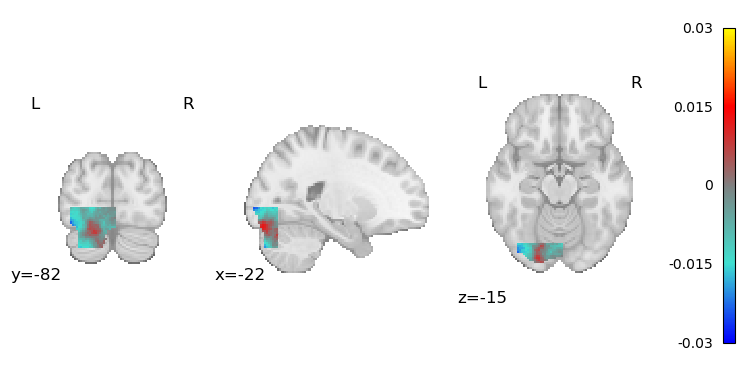

In [6]:
import matplotlib.colors
from nilearn import plotting
def RDMcolormapObject(direction=1):
    """
    Returns a matplotlib color map object for RSA and brain plotting
    """
    if direction == 0:
        cs = ['yellow', 'red', 'gray', 'turquoise', 'blue']
    elif direction == 1:
        cs = ['blue', 'turquoise', 'gray', 'red', 'yellow']
    else:
        raise ValueError('Direction needs to be 0 or 1')
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", cs)
    return cmap
cmap = RDMcolormapObject()
plotting.plot_stat_map(img,
                       threshold = 0,
                       draw_cross = False,
                       cmap = cmap,
                       vmax = 0.03,
                       )